# φ2 Hamiltonian Truncation on a Circle Timing Improvement

Builds the truncated Hamiltonian for an interacting scalar field in 1+1D on a circle of radius $r$:

$$H_\text{eff} = H_0 + \frac{m_V^2}{2} H_2$$


and studies how the energy gap $E_1^+ - E_0$ converges as the energy cutoff $E_\mathrm{max}\to\infty$.

Reference: arXiv:2507.15941

In [1]:
import math

import numpy as np
import scipy.sparse as sp

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns



from collections import Counter, defaultdict
import csv

%matplotlib inline

In [2]:
import scienceplots
plt.style.use('science')

plt.rcParams.update({
    'figure.figsize': (6, 4),
    'figure.dpi': 120,
    'savefig.dpi': 300,
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 13,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'lines.linewidth': 1.8,
    'lines.markersize': 5,
    'axes.linewidth': 0.9,
    'grid.linewidth': 0.5,
    'grid.alpha': 0.4,
    'xtick.major.size': 4,
    'ytick.major.size': 4,
    'xtick.minor.visible': True,
    'ytick.minor.visible': True,
    'legend.frameon': True,
    'legend.framealpha': 0.8,
    'legend.edgecolor': '0.8',
    'figure.constrained_layout.use': True,
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans', 'Arial'],
})

## 1. Single-particle energy and mode indexing

Modes are labelled by magnitude $l \ge 0$ (momentum $\pm l/r$) and sign $\sigma = \pm 1$.
States are stored as dictionaries `{...,-l₂:n₂₋,-l₁:n₁₋,l₀:n₀,l₁:n₁₊,l₂:n₂₊,...}`.


In [3]:
def omega(l, mQ, r):
    # State Energy
    return math.sqrt(float(l)*float(l)/(r*r) + mQ*mQ)

def gen_omega_list(lmax, mQ, r):
    # Global variable storing a list of all state energies.
    global omega_list
    omega_list = [omega(abs(l), mQ, r) for l in range(0,lmax+1)]

# --- Helper functions ---
def get_total_occupation_number(state):
    # Returns occupation number for a given state in dictionary format.
    return sum(state.values())


def convert_state_to_list(state, lmax):
    # Returns state held in dictionary to list.
    return [state.get(i, 0) for i in range(-lmax, lmax+1)]


def get_state_energy(state, mQ, r):
    # Returns state energy for state in dictionary format.
    return sum([nl*omega(l, mQ, r) for l, nl in state.items()])

## 2. Basis generation via the change problem

The change problem is essentially how many ways can you make change for some quantity given a set of coins. Here we have any angular momentum state.

`gen_coins` builds a dictionary with all of the ways to create a number by summing smaller numbers. This is stored in the global state `coins` and will allow us to automatically build states in the **zero-total-momentum** sector (`l_total == 0`).
Elements of the `coins` dictionary appear as e.g. `{5:[[5],[4,1],[3,2],[3,1,1],[2,1,1,1],[1,1,1,1,1]}`.

`coin_dict` then turns the global dictionary `coins` into a global frequency dictionary `coinDict`. Elements of `coinDict` appear as, e.g. `{5:[Counter({4:1}),Counter({3:1,1:1}),Counter({2:2},Counter({2:1,1:2}),Counter({1:4})}`. 

`coin_energies` computes a list of energies for each set of coins labelled by `l` in `coins`. As positive and negative `l` states have the same energy, this only needs computing once.



In [4]:
def gen_coinDict(coins):
    #Turns coins into a global counting dictionary, which is easier to perform operations on.
    global coinDict
    coinDict = {}
    for key in coins.keys():
        coinDict[key] = [Counter(reversed(val)) for val in coins[key]]
        

def gen_coins(n_max):
    global coins
    # Creates the coins dictionary if it does not already exist.
    if 'coins' not in globals():
        coins = {}
        coins.setdefault(1,[[1]]) 
        
    # If we have already calculated up to n_max, just return the dictionary.
    if n_max in coins: return(coins)
     

    for i in range(max(coins.keys())+1,n_max+1):
        #This step is a little complicated so I'll break it down into the two parts of the sum:
        #   1. The first part adds [1] to the end of every list for the previous element (e.g. 6:[[6],...] -> 7:[...,[6, 1],...])
        #   2. The second part adds 1 to the final element of the previous interation (e.g. 6:[...,[3,2,1],...]->7:[...,[3,2,2],...]) given the following conditions:
        #       a) If the length of the dictionary is 1, just add one (i.e 6:[[6],..] -> 7:[[7],...])
        #       b) If the final two elements of a list are the same, there also exists one where the final two elements differ by two (e.g. 6:[...,[3,3],[4,2],...]).
        #          Without input, this would result in duplicate entries. Therefore, the final two elements must not be equal for this step.

        coins[i] = [cns[:-1]+[cns[-1]+1] for cns in coins[i-1] if (len(cns)==1 or cns[-2]!=cns[-1])] + list(map(lambda x:x+[1], coins[i-1])) 
        #coins[i] = sorted(coins[i], key=len) #Not sure this helps. But re-ordering the coin dictionary after creation in terms of occupation number.
        
    # Creating a counting dictionary version of this as it is easier to perform operations on.
    gen_coinDict(coins)
    return coins


def coin_energies(l,mQ,r):
    #Computes the energies of each possible change.
    return [sum(map(lambda c: omega(c, mQ, r), change)) for change in coins[l]]
            

In [4]:
#Example of the coins. 
gen_coins(4)
#Just printing states 3 and 4.
for i in range(3,5):
    print(f'lmax = {i}')
    for change in coins[i]:
        print(f'Coins = {change}, Energy = {sum(map(lambda c: omega(c, 1, 1), change))}')

lmax = 3
Coins = [3], Energy = 3.1622776601683795
Coins = [2, 1], Energy = 3.6502815398728847
Coins = [1, 1, 1], Energy = 4.242640687119286
lmax = 4
Coins = [4], Energy = 4.123105625617661
Coins = [2, 2], Energy = 4.47213595499958
Coins = [3, 1], Energy = 4.576491222541475
Coins = [2, 1, 1], Energy = 5.06449510224598
Coins = [1, 1, 1, 1], Energy = 5.656854249492381


## Generating the set of basis states

`gen_reduced_basis` builds all occupation-number states with energy ≤ `e_max`, by `l` iterating up to `lmax` and each time merging two `coinDicts` together (one with negative angular momentum). Zero momentum states are then added up to `e_max`. This produces all ways to build states with `l_total == 0`.

To note about this particular method:

1. States are stored in dictionary form i.e. `{l:nl,...}` where `l` is the angular momentum and `nl` is the corresponding occupancy number.

2. This particular method only produces one in a pair of asymmetric states about `l=0`. For example `{-3:1,1:3}` would be asymmetric. For larger `e_max` just less than 1/2 of the states are asymmetric so this aids in reducing computation time later.

3. States are produced with the ordering such that `l` goes from most negative to most positive for each state in the basis.

4. a `conversionDict` is concurrently produced which maps indices from the reduced to full basis (including asymmetric pairs). Note asymmetric pairs carry the same index at this stage, where it is understood you will have to manually index +1 to the flipped companion state as required. The next state will have index+2.

In [5]:
def gen_basis(lmax, e_max, mQ, r):
    iterList = set({0}) # List of states to iterate over.

    #l=0:
    result = [{}] # The empty state.

    for i in range(1, int(math.floor(e_max/mQ)) + 1): # Adding l=0 states up to the maximum possible number allowed before reaching e_max.
        result+=[{0: i}] 
        iterList.add(i)

    #l>0:
    # ix is the running state index which we set to one above the maximum l=0 occupancy.
    # asymList is a set (hashable) containing the indices of asymmetric states.
    # runner keeps track of how many asymmetric states there have previously been to produce the conversion dict.
    ix = int(math.floor(e_max/mQ))+1
    
    
    for l in range(1,lmax+1):
        gen_coins(l) # All ways of making up to lmax with smaller numbers
        gen_coinDict(coins) # Generates a dictionary version
        coinEnergies = coin_energies(l,mQ,r) # Energies for each set of coins.

        # Iterate through positive (ii, ci) and negative (jj, cj) momenta, then merge dictionaries.
        for ii,ci in enumerate(coinDict[l]):
            for jj,cj in enumerate(coinDict[l]):
                if jj>=ii: # Only make one copy of each asymmetric state.

                    #Build a temporary energy for the state so we can 
                    # A) figure out if it exceeds e_max.
                    # B) add l=0 states successively up to e_max.
                    e_temp = e_max - coinEnergies[ii] - coinEnergies[jj]
                    
                    if e_temp > 0: #Fill up l=0 state up to e_max.

                        # Merge positive and negative l states, with total l=0. 

                        negative_cj = {-jjj:cjj for jjj,cjj in reversed(cj.items())} # 'reversed' operation here gives correct l-ordering in the state dictionary. NOTE this is not strictly guaranteed to be maintained so we should adjust this.
                        
                        
                        result+=[ negative_cj | ci ]
                       
                        # Increase state index.
                        iterList.add(ix)
                        ix += 1

                        if ii!=jj: 
                            # Populating the asymList dictionary as states are asymmetric.
                            
                            negative_ci = {-iii:cii for iii,cii in reversed(ci.items())}
                            result += [ negative_ci | cj ]
                        
                            ix += 1



                        # Now adding successively more l=0 states up to total e_max.
                        for i in range(1, int(math.floor(e_temp/mQ)) + 1):

                            # Adding successively more l=0 states up to e_max in the center of the dictionary.
                            result+=[ negative_cj | {0:i} | ci ]
                            
                            iterList.add(ix)
                            ix += 1
                            
                            if ii!=jj: 
                                # Populating the asymList dictionary as states are asymmetric.
 
                                result += [ negative_ci | {0:i} | cj ]
                                ix += 1
                            
                        
                
    return (result, iterList)

In [6]:
#Helper function which calculates the maximum angular momentum pairs which can be produced, still below e_max.
def effective_lmax(lmax, e_max, mQ, r):
    if mQ**2 < e_max**2 / 4:
        return int(min(lmax, math.floor(math.sqrt(max(0, r**2*(e_max**2/4 - mQ**2))))))
    return 0

In [7]:
# Convert the hashable basis to dictionary format.
def basis_to_dict(hashable_basis):
    full_basis_dict = []
    for state in hashable_basis.keys():
        full_basis_dict.append(dict(state)) # dict() wrapper converts tuple to dict.
        
    return full_basis_dict

## 3. Basis Generation Timing Between 2110.08273 Method and New Method

Must compute the timing with 2110.08237 in a different notebook and import as "benchmark_basisgen_results.csv"

In [31]:
# Hamiltonian Parameters.
mQ = 1.; r = 1.

# Lists to hold the timing result and basis lengths.
execution_times = []; len_basis = []
emax_list = range(5,25) #Test Range of E_max.

if 'coins' in globals():
    del coins #For fairness, reset the coins dictionary at the beginning (and each time after).


# --- Running the data creation ---


# 1. Iterate over emax_list
for emax in emax_list:
    print(f"E_max: {emax}")
    lmaxeff = effective_lmax(emax,emax,mQ,r)
    
    # Using timeit to get accurate generation timings.
    duration = %timeit -o gen_basis(lmaxeff,emax,mQ,r)
    # Generating the basis via the above method so we can find it's length.
    basis,_ = gen_basis(lmaxeff,emax,mQ,r)
    
    # Adding execution timings and full basis length to the result.
    execution_times.append(duration.average)
    len_basis.append(len(basis))
    
    del coins #For fairness, reset the coins dictionary each time.
    

E_max: 5
7.92 μs ± 62.9 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)
E_max: 6
9.8 μs ± 98.9 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)
E_max: 7
21.4 μs ± 225 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
E_max: 8
26.6 μs ± 764 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
E_max: 9
50.4 μs ± 378 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
E_max: 10
62 μs ± 565 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
E_max: 11
112 μs ± 818 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
E_max: 12
136 μs ± 989 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
E_max: 13
229 μs ± 697 ns per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
E_max: 14
286 μs ± 474 ns per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
E_max: 15
462 μs ± 3.16 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
E_max: 16
575 μs ± 12.3 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
E_ma

--- Benchmark Params ---
mQ = 1, r = 1.0


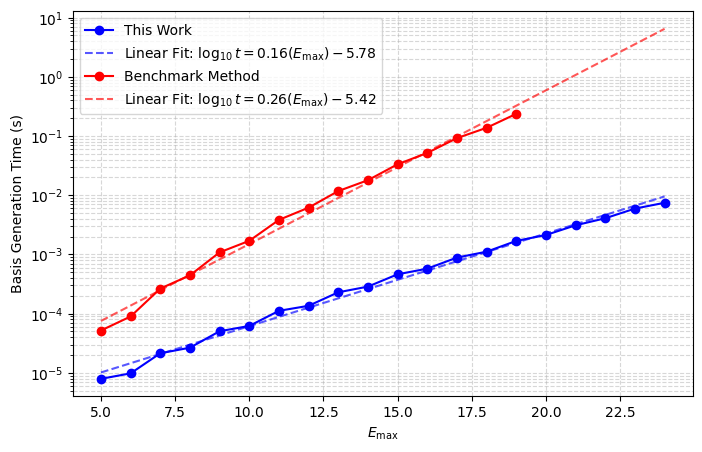

In [32]:

# --- Run the Plot ---

# 2. Importing comparison timings. This file is produced from the code of https://arxiv.org/abs/2110.08273 and imported here.
csv_filename = "benchmark_basisgen_results.csv"
execution_times_prev = []; emax_list_prev = []
with open(csv_filename, mode="r") as file:
    reader = csv.reader(file)
    
    # Prints Hamiltonian parameters for benchmark. Confirm that these are the same in-use here!
    print('--- Benchmark Params ---')
    print(''.join(next(reader)))
    
    # Skips header for e_max list.
    next(reader) 
    emax_list_prev = list(map(float,next(reader))) #Saves e_max list and converts to float.
    
    next(reader)  # And skips Header for result array.
    for row in reader:
        execution_times_prev.append(float(row[1])) # Convert time back to float
        
# 3. Export results to a CSV file
csv_filename = "partition_basisgen_results.csv"
with open(csv_filename, mode="w", newline="") as file:
    writer = csv.writer(file)
    writer.writerow(f"mQ = {mQ}, r = {r}")
    writer.writerow("EMax List")
    writer.writerow(emax_list)
    writer.writerow(["Input Value", "Execution Time (Seconds)"])  # Headers
    writer.writerows(zip(emax_list,execution_times))

# 3. Prepare the plot:
fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.set_xlabel(r'$E_\text{max}$', color='black')
ax1.set_ylabel('Basis Generation Time (s)')
ax1.set_yscale('log')
ax1.tick_params(axis='x', labelcolor='black')
ax1.grid(True, which="both", linestyle='--', alpha=0.5)

# 4. First degree polynomial fit to the timing data.
coef_new = (np.polyfit(emax_list, np.log10(execution_times), 1))
coef_old = (np.polyfit(emax_list_prev, np.log10(execution_times_prev), 1))
poly_new = np.poly1d(coef_new)
poly_old = np.poly1d(coef_old)
xs = np.linspace(emax_list[0],emax_list[-1])

# 5. Plot the results:
ax1.plot(emax_list, execution_times, marker='o', linestyle='-', color='b', label='This Work')
ax1.plot(xs, 10**poly_new(xs), linestyle='--', color='b', alpha=0.66, 
        label= rf'Linear Fit: $\log_{{10}} t = {coef_new[0]:.2f} (E_\text{{max}}) {coef_new[1]:+.2f}$')

ax1.plot(emax_list_prev, execution_times_prev, marker ='o', linestyle='-', color='r', label='Benchmark Method')
ax1.plot(xs, 10**poly_old(xs), linestyle='--', color='r', alpha=0.66, 
        label= rf'Linear Fit: $\log_{{10}} t = {coef_old[0]:.2f} (E_\text{{max}}) {coef_old[1]:+.2f}$')

ax1.legend()


plt.savefig('basis_generation_timing.pdf',format='pdf')


## 3. State Occupation Plot

RuntimeError: Colorbar layout of new layout engine not compatible with old engine, and a colorbar has been created.  Engine not changed.

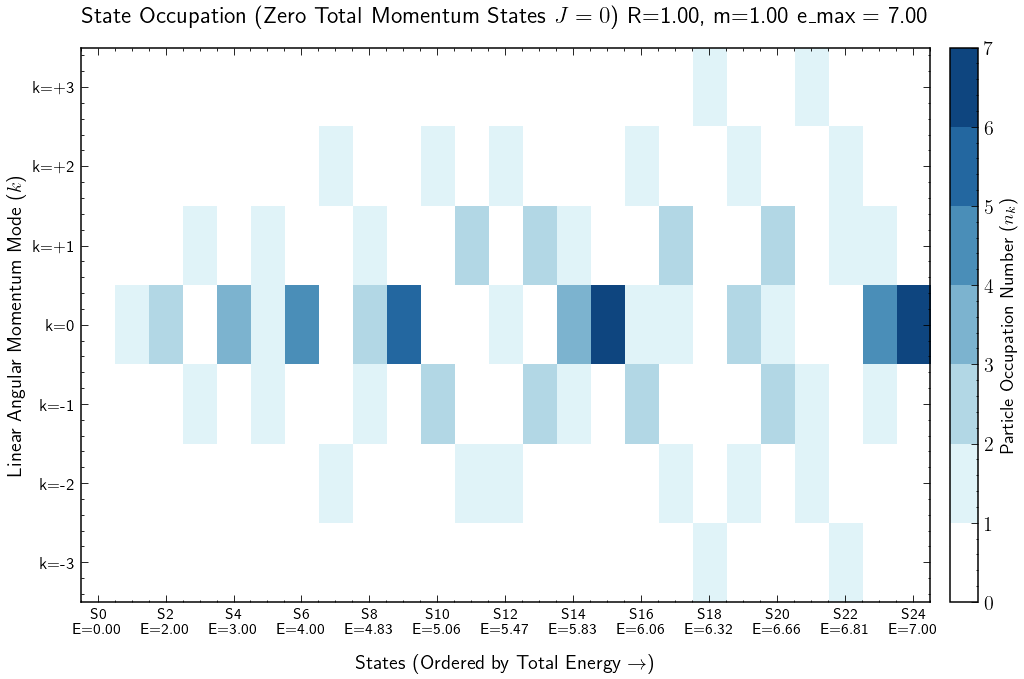

In [8]:
# Hamiltonian Truncation Perameters.
mQ = 1; r = 1.; e_max=7; lmaxeff = effective_lmax(e_max,e_max,mQ,r)

# Generate the basis.
basis, iterList = gen_basis(lmaxeff,e_max,mQ,r)


# Possible Angular Momenta
modes = list(range(-lmaxeff, lmaxeff+1))


# --- Sort states by energies (E = sum(sqrt(1 + k^2))) ---
sorted_states = []
# Computing the energies
state_energies = []
for state in basis:
    state_energies.append(sum([nl*omega(l, mQ, r) for l, nl in state.items()]))

# Sorting the states by energy.
sorted_states=[x for x, _ in sorted(zip(basis, state_energies), key=lambda pair: pair[1])]
sorted_energies=sorted(state_energies)

# --- Construct the Grid of Angular Momenta on the y-axis with States of Increasing Energies on x-axis ---
grid_matrix = np.zeros((len(modes), len(sorted_states)))
for col_idx, stateDict in enumerate(sorted_states):
    grid_matrix[:, col_idx] = [stateDict[x] if x in stateDict else 0 for x in modes]


# --- Plotting the Grid Heatmap ---
fig, ax = plt.subplots(figsize=(11, 6))

#DISCRETE COLOUR MAP for the plot. Add more colours if more than 10 occupation number required.:
blue_gradient = [
    '#ffffff', '#e0f3f8', '#b2d7e5', '#7cb3cf', '#4a8eb8',
    '#2367a0', '#0e457f', '#022659', '#001035', '#000314'
]
blue_cmap = ListedColormap(blue_gradient[:int(max(np.ndarray.flatten(grid_matrix)))])
# origin='lower' keeps negative momentum at the bottom and positive at the top
cax = ax.imshow(grid_matrix, cmap=blue_cmap, aspect='auto', origin='lower',interpolation='nearest')

# Axis Configuration (Y-Axis: Momentum)
mode_labels = [f"k={m}" if m <= 0 else f"k=+{m}" for m in modes] # Separating positive and negative angular momenta.
ax.set_yticks(np.arange(len(modes)))
ax.set_yticklabels(mode_labels, fontsize=10)
ax.set_ylabel("Linear Angular Momentum Mode ($k$)", fontsize=12)

# Axis Configuration (X-Axis: Energy Sorted States)
state_labels = [f"S{i}\nE={item:.2f}" for i, item in enumerate(sorted_energies)]
if len(state_labels)>15:
    # Reducing the number of state labels if it becomes too large, as unreadable.
    _state_labels=state_labels[::int(math.ceil(len(state_labels)/15))]
    ax.set_xticks(np.arange(0,len(sorted_states),int(math.ceil(len(state_labels)/15))))
    ax.set_xticklabels(_state_labels, fontsize=9)

else:
    ax.set_xticks(np.arange(0,len(sorted_states)))
    ax.set_xticklabels(state_labels, fontsize=9)

ax.set_xlabel("States (Ordered by Total Energy $\\rightarrow$)", fontsize=12, labelpad=10)

ax.set_title(f"State Occupation (Zero Total Momentum States $J=0$) R={r:.2f}, m={mQ:.2f} e_max = {e_max:.2f}", fontsize=14, pad=15)

# Setup a clean discrete colorbar for occupation levels
max_occ = int(np.max(grid_matrix))
cbar = fig.colorbar(cax, ax=ax, ticks=np.arange(max_occ + 1), pad=0.02)
cbar.set_label('Particle Occupation Number ($n_k$)', fontsize=11)

plt.grid(False) # Turn off the default global grid overlay to keep image clean
plt.tight_layout()
plt.show()

## 4. Raising and falling factorials.

In [9]:
def falling_factorial(x,k):
    # x is the value and k is the number of falling factorial steps to take.
    return math.prod(x - i for i in range(k))

def raising_factorial(x,k):
    # x is the value and k is the number of raising factorial steps to take.
    return math.prod(x + i for i in range(k))

## 5. Transition Matrix

Just considering `H_eff = H₀ + (g/24)·H4`.

In [10]:
def basis_even(basis, iterList):  
    # Collecting only even states, creating a conversion dictionary and a hashable basis.
    # The hashable basis is of the form {tuple representation of state: state index}
    even_basis = []; even_hashable_states = {tuple({}):0}; even_iterlist = set()
    
    basislen = len(basis); runner = 0
    
    for ix in iterList:
        s = basis[ix]
            
        if sum(s.values()) % 2 == 0:
            even_basis += [s]
            even_hashable_states[tuple(s.items())] = runner
            even_iterlist.add(runner)
            runner += 1
            

            if ix<basislen-1 and ix+1 not in iterList:
                
                a_s = basis[ix+1]
                even_basis += [a_s]
                even_hashable_states[tuple(a_s.items())] = runner
                runner += 1

                    

    return (even_basis, even_hashable_states, even_iterlist)


def basis_odd(basis, iterList):  
    # Collecting only odd states, creating a hashable basis.
    # The hashable basis is of the form {tuple representation of state: state index}
    odd_basis = []; odd_hashable_states = {tuple({}):0}; odd_iterlist = set()
    
    basislen = len(basis); runner = 0
    
    for ix in iterList:
        s = basis[ix]
            
        if sum(s.values()) % 2 != 0:
            odd_basis += [s]
            odd_hashable_states[tuple(s.items())] = runner
            odd_iterlist.add(runner)
            runner += 1

            if ix<basislen-1 and ix+1 not in iterList:
                
                a_s = basis[ix+1]
                odd_basis += [a_s]
                odd_hashable_states[tuple(a_s.items())] = runner
                runner += 1

    return (odd_basis, odd_hashable_states, odd_iterlist)


def basis_all(basis, iterList):  
    # Collecting all states, creating a hashable basis.
    # The hashable basis is of the form {tuple representation of state: state index}
    all_basis = []; all_hashable_states = {tuple({}):0}; all_iterlist = set()
    
    basislen = len(basis); runner = 0
    
    for ix in iterList:
        s = basis[ix]
        all_basis += [s]
        all_hashable_states[tuple(s.items())] = runner
        all_iterlist.add(runner)
        runner += 1

        if ix<basislen-1 and ix+1 not in iterList:
            
            a_s = basis[ix+1]
            all_basis += [a_s]
            all_hashable_states[tuple(a_s.items())] = runner
            runner += 1

    return (all_basis, all_hashable_states, all_iterlist)

In [11]:
def transition_matrix_phi2(mQ, mV, r, lmaxeff, basis_dict, hashable_basis, iterList):
    # NOTE:
    # 1. This method adds to the full basis including asymmetric states. 
    # 2. the hashable_basis has the correct indices. basis_dict has only one copy of asymmetric pairs. It is understood that pairs must be consistently, manually added to index+1. The next state will have index+2.
    # 3. Finally note in order to use the hashable_basis, all states MUST be ordered in increasing l.
    
    # phi2 Coupling
    cphi2=mV**2/2

    # --- Now iterating over all zero or two Hamming Distance states. ---
    H_eff = []; cols = []; rows = []
    
    # Compute the size of the full matrix. hashable_basis has an additional zero entry.
    matrixDim = len(hashable_basis)
    

    # Now iterate over states.
    for ix in iterList:
        state = basis_dict[ix]
        
        # --- --- Pre Computation --- ---
        # Pre-Computing some Properties for speed later.
        ixPaired=False
        if ix<matrixDim-1 and ix+1 not in iterList: # If the next term in the sequence is skipped, this is an asymmetric pair.
            ixPaired=True

        # --- --- Adding To The Diagonal (H_0) --- ---
        # Add energy to the diagonal.
            
        if ixPaired:
            # If the state is asymmetric, buff H_eff with an additional entry on the next diagonal.
            res = get_state_energy(state, mQ, r)
            H_eff.extend([res,res]); rows.extend([ix,ix+1]); cols.extend([ix,ix+1])
        else:
            # Otherwise just add to the current diagonal.
            res = get_state_energy(state, mQ, r)
            H_eff.extend([res]); rows.extend([ix]); cols.extend([ix])
            

        # --- --- Adding H_2 Operations --- ---
        # All options here first begin removing two occupants from the state so beginning with this.
        for l,nl in state.items():
            el = omega_list[abs(l)]
            base_res = np.sqrt(nl/el)
            

            # --- 1. Remove one state and add one state back ---
            # --- ---- Note for the following operation, multiple reductions/additions will likely occur to the same state. coo_matrix then sums all entries in the same location.
            
            # Note here we must add and remove only from the same state such that l_total == 0.
            res = (cphi2) * (base_res ** 2) * 2


            # Apply the Diagonal with the operation.
            # Computing the transition matrix element following Eq. 3.7 in the draft.
            if ixPaired:
                # If asymmetric, add to _ix diagonal and _ix+1 diagonal.
                H_eff.extend([res, res]); rows.extend([ix,ix+1]); cols.extend([ix,ix+1])
            else:
                # If not asymmetric, only add to _ix diagonal.
                H_eff.extend([res]); rows.extend([ix]); cols.extend([ix])
                
                
            
            # We have to remove a state with momentum -l in order to maintain l_total = 0.
            if -l in state.keys() and state[-l]!=0: # Verifying that we are able to remove -l from the state, and not have zero transition element.
                if l==0 and state[l]<2: continue
                
                
                
                if l != 0:
                    n_l = state[-l]
                    base_res *= np.sqrt(n_l/el)
                    state[l] -=1
                    state[-l]-=1
                else: 
                    base_res *= np.sqrt((nl-1)/el) 
                    state[0] -= 2

                
                res = (cphi2) * base_res
                
                final_state = tuple((a,b) for a,b in state.items() if b!= 0)
            
                # Look up the new target state in the hashable_basis table to find the index of the new state.
                iy = hashable_basis.get(final_state)
                

                # Adds to H_eff both the transition matrix element for removing and adding (basically a transpose).

                if ixPaired and iy not in iterList: # ix and iy both in a pair, but iy not the iterated of the pair.
                    H_eff.extend([res, res, res, res])
                    cols.extend([ix, iy, ix+1, iy-1]); rows.extend([iy, ix, iy-1, ix+1])
                        
                elif ixPaired and iy+1 not in iterList: # ix and iy both in a pair, and both the iterated pair.
                    H_eff.extend([res, res, res, res])
                    cols.extend([ix, iy, ix+1, iy+1]); rows.extend([iy, ix, iy+1, ix+1])

                elif ixPaired: # Just ix in a pair.
                    H_eff.extend([res, res, res, res])
                    cols.extend([ix, iy, ix+1, iy]); rows.extend([iy, ix, iy, ix+1])    
                    
                elif iy+1 not in iterList:  # Just iy in a pair.
                    H_eff.extend([res, res, res, res])
                    cols.extend([ix, iy, ix, iy+1]); rows.extend([iy, ix, iy+1, ix]) 
                    
                else:   
                    H_eff.extend([res, res])
                    cols.extend([ix, iy]); rows.extend([iy, ix])
                    
                # Return new_dict back to it's original form.
                state[-l] += 1
                state[l] += 1
                


    # Convert to sparse matrix format. Note there are some diagonal entries in the same location, which is summed by coo_matrix. These are not double-counted states, but contributions from different operations which are supposed to sum.
    H_eff = np.array(H_eff); rows = np.array(rows); cols = np.array(cols)
    return sp.coo_matrix((H_eff,(rows, cols)), shape=(matrixDim,matrixDim))

RuntimeError: Colorbar layout of new layout engine not compatible with old engine, and a colorbar has been created.  Engine not changed.

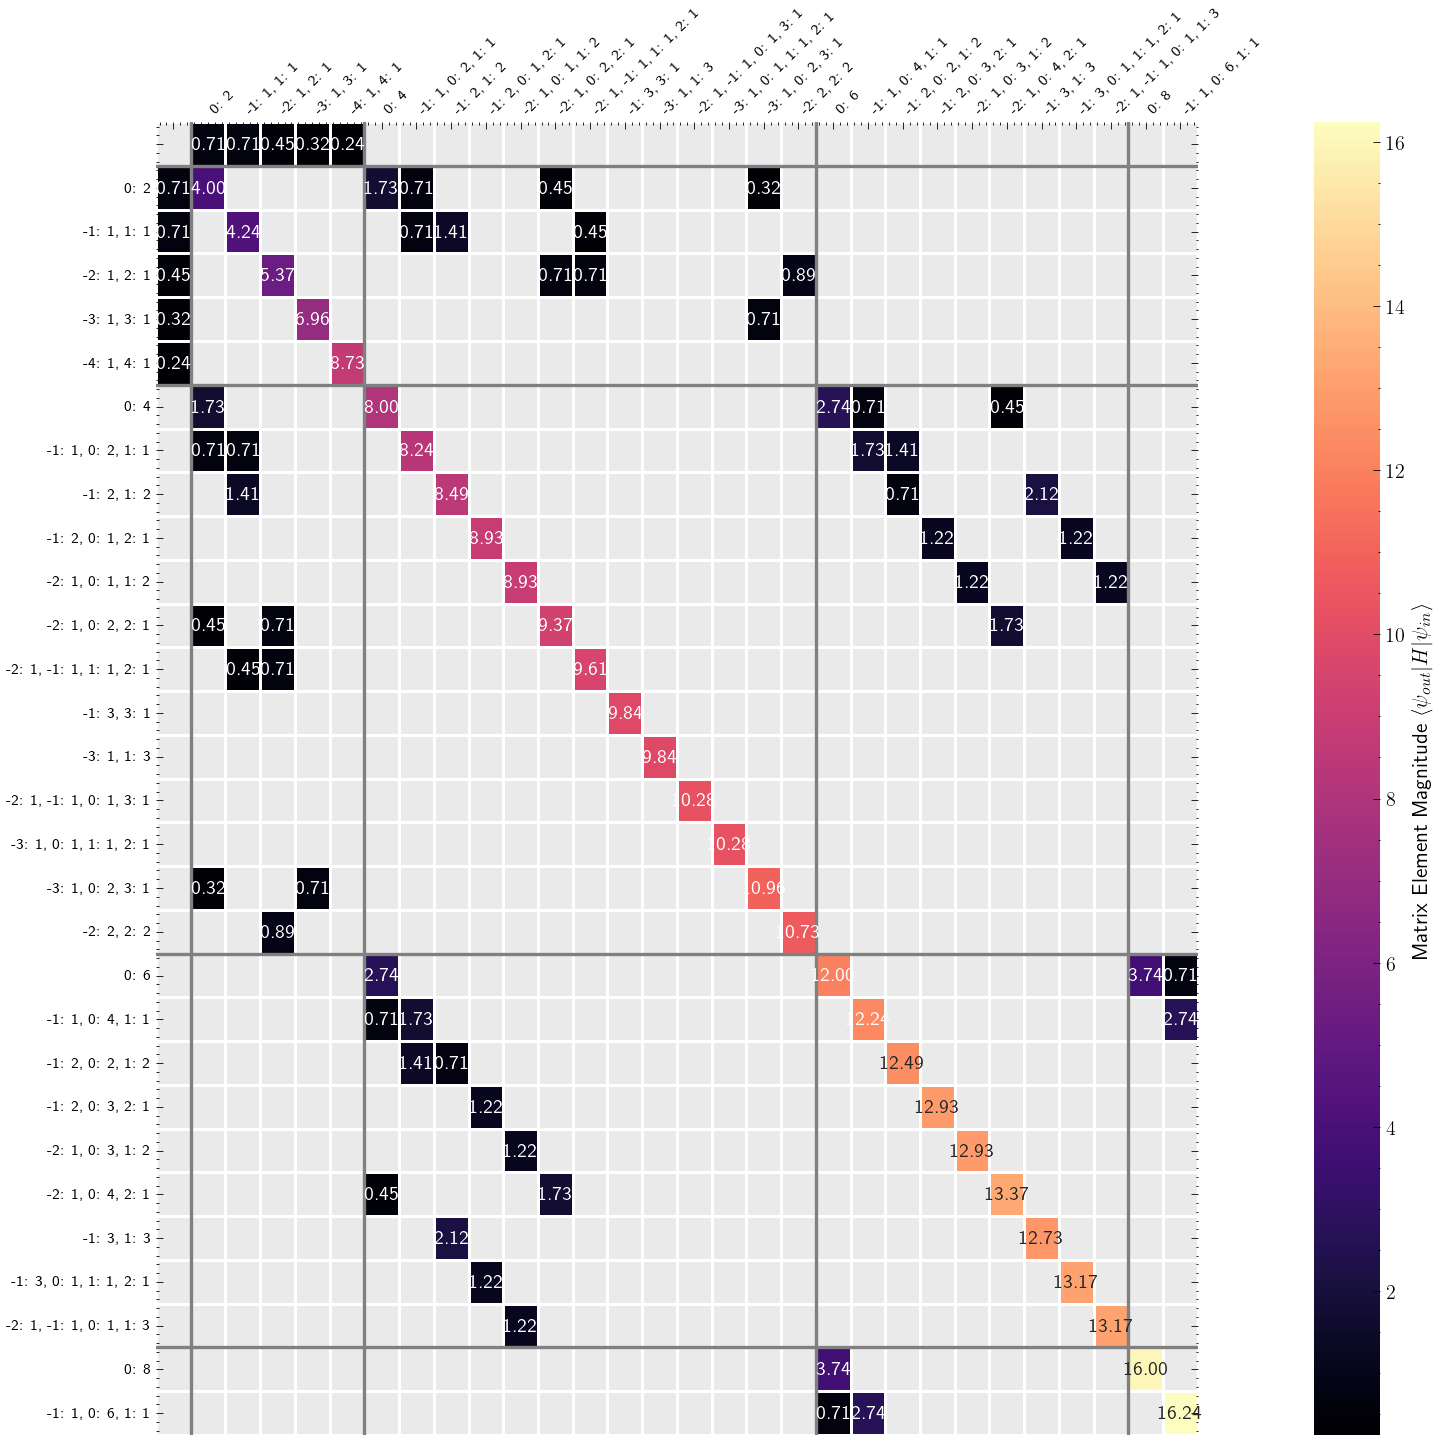

In [12]:
# --- Hamiltonian Parameters for Test ---
g = 1.; mV = 1.; mQ = 1.; r = 1.; e_max=9; lmaxeff = effective_lmax(e_max,e_max,mQ,r)

# --- Generate the Basis ---
reduced_basis, hashable_basis, iterList = basis_even(*gen_basis(lmaxeff,e_max,mQ,r)) #Select Even Basis States Only.
# Generate useful lists of energies.
gen_omega_list(lmaxeff, mQ, r)

# --- Run the transition matrix element calculation in phi^2 ---
H_eff_coo=transition_matrix_phi2(mQ, mV, r, lmaxeff, reduced_basis, hashable_basis, iterList)

# --- Prepare the Plot ---

# 1. Convert the reduced basis into the buffed version with both anti-symmetric pairs.
full_basis=basis_to_dict(hashable_basis)


# 2. Compute properties.
occupation_numbers = np.array([get_total_occupation_number(state) for state in full_basis]) # State Occupation Number for each in basis.
full_state_energies = np.array([get_state_energy(state, mQ, r) for state in full_basis]) ## State Energies for each in basis.


# 3. Sort the basis using lexsort, primarily by occupation number, secondly by energy.
double_sorted_indices = np.lexsort((full_state_energies, occupation_numbers)) 
sorted_full_basis = [full_basis[i] for i in double_sorted_indices]
H_sorted = H_eff_coo.toarray()[double_sorted_indices, :][:, double_sorted_indices]


# 4. Identify unique occupation values and their starting indices
# (Using the sorted array guarantees these indices mark the boundaries)
unique_occ, boundaries_vec = np.unique(occupation_numbers[double_sorted_indices], return_index=True)

# 5. Map the boundaries to a dictionary
boundaries = dict(zip(unique_occ, boundaries_vec))


# --- --- Plot --- ---

# --- State labels ---
verbose_labels = []
for state in sorted_full_basis:
    verbose_labels.append("{"+", ".join(f"{key}: {value}" for key, value in sorted(state.items()) if value !=0)+"}") # Such that they 'look' like a dictionary of states on the plot.

# --- Boundaries between occupation numbers for the plot ---
state_vecs = np.array([convert_state_to_list(state, lmaxeff) for state in sorted_full_basis])
boundaries = np.where(np.diff(np.sort(np.sum(state_vecs, axis=1))))[0] # List of places where state occupation number changes.
boundaries[0] = 0 # Fixing the zero entry.

# --- Plotting the Heatmap Matrix ---
plt.figure(figsize=(12, 12))

zero_mask = (H_sorted == 0.0) # So that we don't have an overcrowded plot.
ax = sns.heatmap(
    H_sorted, 
    annot=True, 
    fmt=".2f", 
    cmap="magma", 
    linewidths=0.8,
    xticklabels=verbose_labels, 
    yticklabels=verbose_labels,
    mask=zero_mask,
    cbar_kws={'label': 'Matrix Element Magnitude $\\langle \\psi_{out} | H | \\psi_{in} \\rangle$'}
)


# Drawing separation dividers between states of differing occupation number.
for b in boundaries:
    ax.axvline(x=b+1, linewidth=2, color="grey")
    ax.axhline(y=b+1, linewidth=2, color="grey")


ax.xaxis.tick_top() # Layout of x-axis.
ax.xaxis.set_label_position('top')
ax.set_facecolor('#eaeaea') # Soft gray for zero elements
plt.xticks(rotation=45, ha='left', fontsize=9)
plt.yticks(rotation=0, fontsize=9)

plt.savefig('phi2_matrix_creation_r{r}mQ{mQ}mV{mV}emax{e_max}.pdf',format='pdf')
plt.tight_layout()
plt.show()


## Timing Code to Compare with https://arxiv.org/abs/2110.08273

E_max: 10
 reduced basis length = 25 and number of asymmetric states = 10
 total basis length = 45
161 μs ± 2.31 μs per loop (mean ± std. dev. of 4 runs, 10,000 loops each)
E_max: 11
 reduced basis length = 25 and number of asymmetric states = 19
 total basis length = 72
249 μs ± 1.81 μs per loop (mean ± std. dev. of 4 runs, 1,000 loops each)
E_max: 12
 reduced basis length = 25 and number of asymmetric states = 31
 total basis length = 104
354 μs ± 1.62 μs per loop (mean ± std. dev. of 4 runs, 1,000 loops each)
E_max: 13
 reduced basis length = 25 and number of asymmetric states = 53
 total basis length = 161
563 μs ± 11.5 μs per loop (mean ± std. dev. of 4 runs, 1,000 loops each)
E_max: 14
 reduced basis length = 25 and number of asymmetric states = 84
 total basis length = 235
794 μs ± 13 μs per loop (mean ± std. dev. of 4 runs, 1,000 loops each)
E_max: 15
 reduced basis length = 25 and number of asymmetric states = 132
 total basis length = 351
1.2 ms ± 18.3 μs per loop (mean ± std

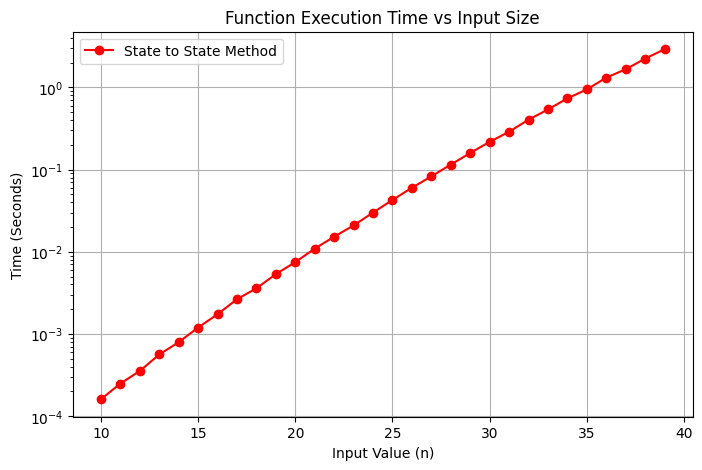

In [20]:
# 1. Preparing the parameters for the timing run, and lists for results.
mQ = 1; r = 1; mV = 1 # Hamiltonian parameters.
execution_times = []; basis_lengths = []
emax_list = range(10,40) #EMax range.

# 2. Run through emax list and time creation.
for emax in emax_list:
    print(f"E_max: {emax}")

    # Timing the transition matrix creation.
    # Compute the effective lmax.
    lmaxeff = effective_lmax(emax,emax,mQ,r)
    # Generate the basis and energy list.
    reduced_basis, hashable_basis, iterList  = basis_even(*gen_basis(lmaxeff,emax,mQ,r))
    gen_omega_list(lmaxeff, mQ, r)

    # Just to keep track of the basis length and how much we've saved by only going through one set of an anti-symmetric pair.
    print(f' reduced basis length = {len(basis)} and number of asymmetric states = {len(hashable_basis)-len(iterList)-1}')
    print(f' total basis length = {len(hashable_basis)-1}')

    # Timing: 
    duration = %timeit -o -r4 transition_matrix_phi2(mQ, mV, r, lmaxeff, reduced_basis, hashable_basis, iterList)
    # Add results to relevant lists.
    execution_times.append(duration.average)
    basis_lengths.append(len(basis))


# 3. Export results to a CSV file
csv_filename = "phi2_statetostate_results.csv"
with open(csv_filename, mode="w", newline="") as file:
    writer = csv.writer(file)
    writer.writerow(f"mQ = {mQ}, mV = {mV}, r = {r}") # To keep track of HT parameters.
    writer.writerow("EMax List")  # Writes emax list onto file header.
    writer.writerow(emax_list) # To keep track of the relevant emax's used.
    writer.writerow(["Input Value", "Execution Time (Seconds)"])  # Headers
    writer.writerows(zip(emax_list,execution_times))

# 4. Plot the results
plt.figure(figsize=(8, 5))
plt.yscale('log')
plt.plot(emax_list, execution_times, marker='o', linestyle='-', color='r', label="State to State Method")
plt.title('Function Execution Time vs Input Size')
plt.xlabel('Input Value (n)')
plt.ylabel('Time (Seconds)')
plt.legend()
plt.grid(True)
plt.show()

### Sparsity Scaling Plots

In [13]:
# 1. Preparing the parameters for the timing run, and lists for results.
mQ = 1; r = 1; g = 4*np.pi # Hamiltonian parameters.
sparsity_frac = []; basis_lengths = []
emax_list = range(10,40) #EMax range.

# 2. Run through emax list and time creation.
for emax in emax_list:
    print(f"E_max: {emax}")

    # Timing the transition matrix creation.
    # Compute the effective lmax.
    lmaxeff = effective_lmax(emax,emax,mQ,r)
    # Generate the basis and energy list.
    dict_basis, hashable_basis, iterList  = basis_all(*gen_basis(lmaxeff,emax,mQ,r))
    gen_omega_list(lmaxeff, mQ, r)

    # Just to keep track of the basis length and how much we've saved by only going through one set of an anti-symmetric pair.

    # Produces the transition matrix
    H_total = transition_matrix_phi2(mQ, mV, r, lmaxeff, dict_basis, hashable_basis, iterList)
    # Add results to relevant lists.
    sparsity_frac.append(H_total.nnz/len(dict_basis)**2)
    basis_lengths.append(len(dict_basis))
    
    print(f' sparsity fraction = {H_total.nnz/len(dict_basis)**2}')
    print(f' basis length = {len(dict_basis)}')


E_max: 10
 sparsity fraction = 0.07277882797731569
 basis length = 92
E_max: 11
 sparsity fraction = 0.04914239726371913
 basis length = 141
E_max: 12
 sparsity fraction = 0.03507936507936508
 basis length = 210
E_max: 13
 sparsity fraction = 0.024324020863742614
 basis length = 313
E_max: 14
 sparsity fraction = 0.01677898312513697
 basis length = 468
E_max: 15
 sparsity fraction = 0.011758889940508383
 basis length = 688
E_max: 16
 sparsity fraction = 0.008445597575072258
 basis length = 997
E_max: 17
 sparsity fraction = 0.006075904365792688
 basis length = 1431
E_max: 18
 sparsity fraction = 0.004343456191925379
 basis length = 2059
E_max: 19
 sparsity fraction = 0.0031367254898571227
 basis length = 2926
E_max: 20
 sparsity fraction = 0.0022833364281964943
 basis length = 4135
E_max: 21
 sparsity fraction = 0.0016766256425270881
 basis length = 5779
E_max: 22
 sparsity fraction = 0.0012277135820017646
 basis length = 8080
E_max: 23
 sparsity fraction = 0.0009100331142817496
 basis

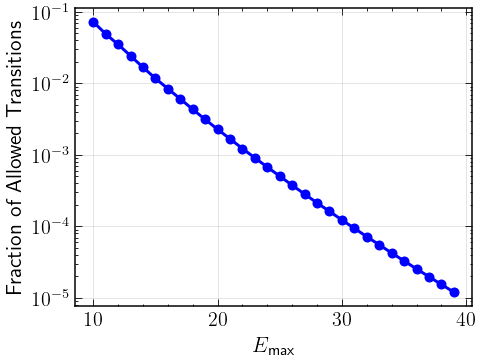

In [16]:
# 4. Plot the results
plt.figure(figsize=(4, 3))
plt.yscale('log')
plt.plot(emax_list, sparsity_frac, marker='o', linestyle='-', color='b')
plt.xlabel(rf'$E_\text{{max}}$')
plt.ylabel('Fraction of Allowed Transitions')
plt.grid(True)
plt.savefig('phi2_sparsity_emax.pdf',format='pdf', bbox_inches="tight", pad_inches=0.1)

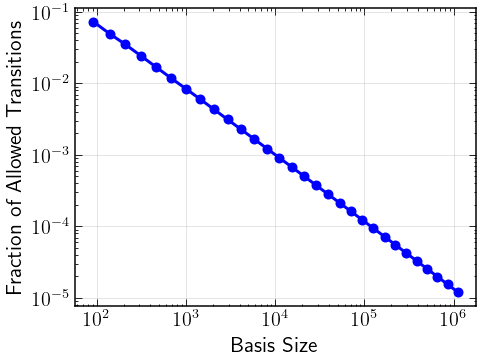

In [17]:
# 5. Plot the results
plt.figure(figsize=(4, 3))
plt.yscale('log')
plt.xscale('log')
plt.plot(basis_lengths, sparsity_frac, marker='o', linestyle='-', color='b')
plt.xlabel(rf'Basis Size')
plt.ylabel('Fraction of Allowed Transitions')
plt.grid(True)
plt.savefig('phi2_sparsity_basislen.pdf',format='pdf', bbox_inches="tight", pad_inches=0.1)